# Descriptive and Inference Statistics

The desciptive statistics summarizes the measures of central tendency, distribution, and the range of data. 

I will use descriptive statistics to summarize -
- Distribution and range of data
- Central Limit Theorem & sampling
- Bootstraping - Apply the ‘Plug-in principle’ to complement CLT inferences
- Confidence intervals
- Hypothesis testing
- Chi-squared tests for independence and categorical relationships
- Analysis Of Variance (ANOVA) for multi-group comparison - check if there are statistcal difference between means of three or more groups.
- Visualization for interpretation

In [1]:
import pandas as pd
from stats_utils import (
    describe_numeric_column, plot_distribution, plot_boxplot_by_target,
    clt_sampling_distribution, calculate_confidence_interval,
    bootstrap_confidence_interval, one_sample_ttest, two_sample_ttest,
    chi_squared_test, anova_test, calculate_z_score
)
df = pd.read_csv('../data/raw/telco-customer-churn-ibm.csv')

## Descriptive Statistics for MonthlyCharges

In [2]:
# Monthly charges
describe_numeric_column(df, 'MonthlyCharges')


Descriptive statistics for MonthlyCharges:
count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64


count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [3]:
# Z-score
calculate_z_score(90, df['MonthlyCharges'].mean(), df['MonthlyCharges'].std())

Z-score: 0.839


0.8387593232231267

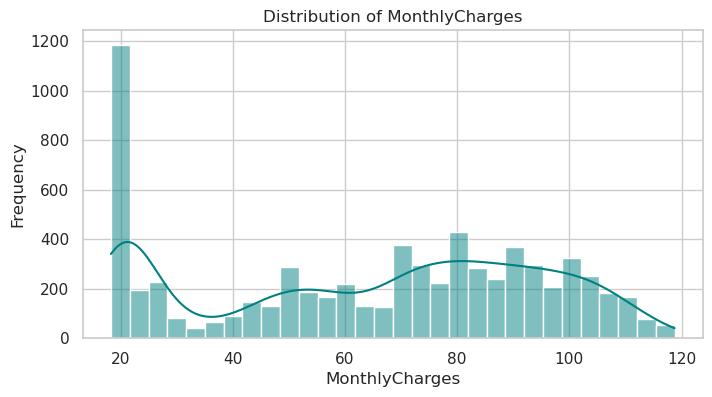

In [4]:
plot_distribution(df, 'MonthlyCharges')

# Confidence Interval for MonthlyCharges
## 95% Confidence Interval for Average MonthlyCharges

In [5]:
# Confidence interval
calculate_confidence_interval(df['MonthlyCharges'])

95% CI for mean: (64.06, 65.46)


(64.05883579770197, 65.46454912349638)

## Central Limit Theorem: Sampling Distribution of the Mean
- the CLT for MonthlyCharges follows a normal distribution

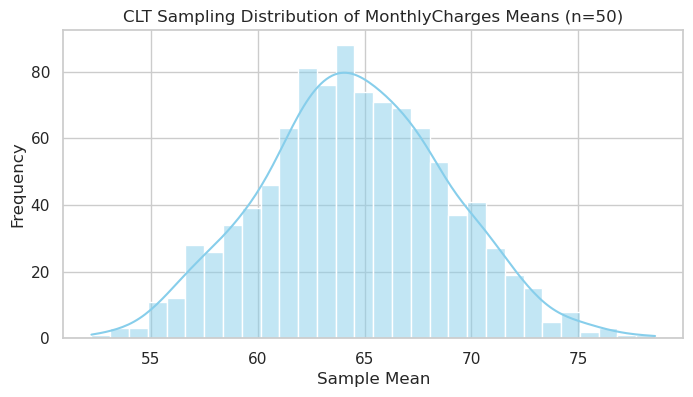

In [6]:
clt_sampling_distribution(df, 'MonthlyCharges')

# Bootstrap Confidence Interval
## Bootstrap Confidence Interval for Mean MonthlyCharges

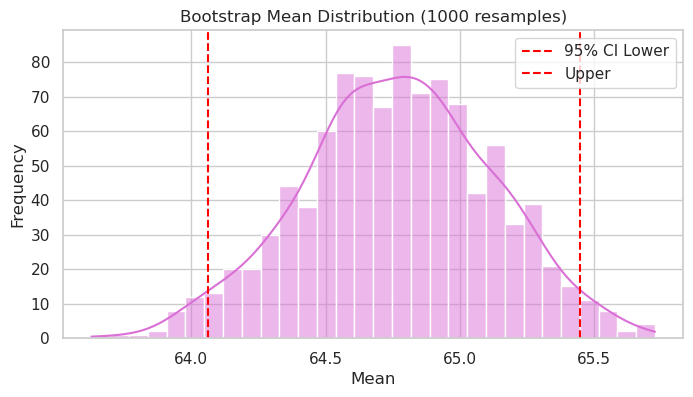

95% bootstrap CI: (64.06, 65.44)


(64.06028592219224, 65.44477956836575)

In [7]:
bootstrap_confidence_interval(df['MonthlyCharges'])

## Hypothesis Testing

In [8]:
# Hypothesis tests
one_sample_ttest(df['MonthlyCharges'], popmean=65)

One-sample t-test: t=-0.665, p=0.506


(-0.664651147898189, 0.5062954103387203)

In [9]:
# Churn vs not churned
churned = df[df['Churn']==1]['MonthlyCharges']
not_churned = df[df['Churn']==0]['MonthlyCharges']
two_sample_ttest(churned, not_churned)

Two-sample t-test: t=nan, p=nan


(nan, nan)

## Chi-squared Test: Is Churn independent of Contract Type?

In [10]:
# Chi-squared test
table = pd.crosstab(df['Churn'], df['Contract'])
chi_squared_test(table)

Chi-squared test: chi2=1184.597, dof=2, p=0.000


(1184.5965720837926,
 5.863038300673391e-258,
 2,
 array([[2846.69175067, 1082.11018032, 1245.198069  ],
        [1028.30824933,  390.88981968,  449.801931  ]]))

## ANOVA: Compare MonthlyCharges across Multiple Contract Types

In [14]:
# ANOVA (e.g., MonthlyCharges by contract type)
groups = [df[df['Contract']==c]['MonthlyCharges'] for c in df['Contract'].unique()]
anova_test(*groups)

ANOVA: F=20.828, p=0.000


(20.828045474730274, 9.575270975935273e-10)